**# SUMMER SCHOOL PROJECT 1 SUBMISSION (PART C)#* **
* **NAME= SHYLA VIJAY**
* **ROLL NO.= 24/A06/064**
* **EMAIL.ID= shyla7611@gmail.com**
* **CONTACT= 7982691483**

# README
1. Dataset Loading & Preprocessing
* Loaded SAR and EO image tensors (.pt files).
* Selected EO bands as per required usecase for each part.
* Converted tensors to [C, H, W] format.
* Added data augmentation: random flips and rotations to improve model generalization.

2. Model Architecture
* Implemented a CycleGAN framework using PyTorch.
* Built a ResNet-based generator with 6 residual blocks.
* Built a PatchGAN discriminator for classifying image patches as real or fake.
* Initialized weights using a normal distribution and used instance normalization.
* Used Instance Normalization and Tanh activation in the generator output.

3. Training Pipeline
* Defined a custom PyTorch dataset class (PairedTensorDataset_NIR_SWIR_RE) for loading paired SAR–EO samples.
* Split data into training and testing sets (80/20).
* Applied augmentations only on training data.
* Used PyTorch DataLoader for efficient mini-batch training.
* Calculated global min/max statistics for SAR and EO images.

4. Loss Functions
* Combined Adversarial Loss with Structural Similarity Index (SSIM) Loss to guide the generator.
* SSIM Loss helped improve the perceptual quality and structure preservation of the generated EO images.

5. Evaluation & Outputs
* Generated translated EO images from SAR inputs using the trained generator.
* Saved sample translated images in a folder (generated_samples/) for visual comparison.

Tools Used
PyTorch, torchvision, NumPy, Matplotlib

Environment: Kaggle Notebooks



In [21]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np


# ==== Configs ====
DATA_DIR = "/kaggle/input/processedimagesc/processed"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 256
BATCH_SIZE = 1
EPOCHS = 10
LAMBDA_CYCLE = 10
LAMBDA_ID = 5
RESUME_CHECKPOINT = None  # Path to checkpoint to resume

# ==== Verify .pt Shapes ====
def check_tensor_shapes(root_dir):
    files = os.listdir(root_dir)
    sar_files = sorted([f for f in files if f.endswith("_sar.pt")])
    eo_files = sorted([f for f in files if f.endswith("_eo.pt")])

    all_good = True
    for sar_file, eo_file in zip(sar_files, eo_files):
        sar_path = os.path.join(root_dir, sar_file)
        eo_path = os.path.join(root_dir, eo_file)

        try:
            sar_tensor = torch.load(sar_path)
            eo_tensor = torch.load(eo_path)

            if sar_tensor.ndim != 3 or sar_tensor.shape[:2] != (256, 256):
                print(f" {sar_file} has invalid shape: {sar_tensor.shape}")
                all_good = False
            if eo_tensor.ndim != 3 or eo_tensor.shape[:2] != (256, 256):
                print(f" {eo_file} has invalid shape: {eo_tensor.shape}")
                all_good = False

        except Exception as e:
            print(f" Failed to load {sar_file} or {eo_file}: {e}")
            all_good = False

    if all_good:
        print(" All .pt files are correctly shaped (256, 256, C).")
    else:
        print("❗ Found invalid shapes. Please fix those files.")

check_tensor_shapes(DATA_DIR)

 All .pt files are correctly shaped (256, 256, C).


In [33]:
# ==== Dataset Loader ====
class PairedTensorDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        files = os.listdir(root_dir)
        self.ids = sorted(set(f.split('_')[0] for f in files))

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        file_id = self.ids[idx]
        sar_path = os.path.join(self.root_dir, f"{file_id}_sar.pt")
        eo_path = os.path.join(self.root_dir, f"{file_id}_eo.pt")
        sar = torch.load(sar_path).permute(2, 0, 1).float()
        eo = torch.load(eo_path).permute(2, 0, 1).float()
        return sar, eo

# ==== Load Dataset ====
dataset = PairedTensorDataset(DATA_DIR)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1)
# ===  Dataset Info ===
print(f" Total image pairs (SAR + EO): {len(dataset)}")

# Check unique SAR and EO files
all_files = os.listdir(DATA_DIR)
sar_count = len([f for f in all_files if '_sar.pt' in f])
eo_count = len([f for f in all_files if '_eo.pt' in f])
print(f" SAR files: {sar_count}, EO files: {eo_count}")

# Check dimensions and stats for first sample
sar_sample, eo_sample = dataset[0]
print(f" SAR shape: {sar_sample.shape}, dtype: {sar_sample.dtype}")
print(f" EO shape: {eo_sample.shape}, dtype: {eo_sample.dtype}")
print(f" SAR range: [{sar_sample.min():.2f}, {sar_sample.max():.2f}]")
print(f" EO range:  [{eo_sample.min():.2f}, {eo_sample.max():.2f}]")

# ===  Batch Preview ===
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
sar_batch, eo_batch = next(iter(dataloader))
print(f"\n One batch:")
print(f"   SAR batch shape: {sar_batch.shape}")
print(f"   EO batch shape:  {eo_batch.shape}")
data = torch.load("/kaggle/input/processedimagesc/processed/0000_eo.pt")
print(data.shape)

 Total image pairs (SAR + EO): 784
 SAR files: 784, EO files: 784
 SAR shape: torch.Size([2, 256, 256]), dtype: torch.float32
 EO shape: torch.Size([13, 256, 256]), dtype: torch.float32
 SAR range: [-1.00, 1.00]
 EO range:  [-1.00, 1.00]

 One batch:
   SAR batch shape: torch.Size([4, 2, 256, 256])
   EO batch shape:  torch.Size([4, 13, 256, 256])
torch.Size([256, 256, 13])


In [24]:
# ==== Residual Block ====
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)

# ==== Generator ====
class Generator(nn.Module):
    def __init__(self, in_channels, out_channels, n_residuals=9):
        super().__init__()
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
            out_features *= 2

        for _ in range(n_residuals):
            model += [ResidualBlock(in_features)]

        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
            out_features //= 2

        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, out_channels, 7),
            nn.Tanh(),
        ]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

# ==== Discriminator ====
class Discriminator(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        def block(in_c, out_c, stride):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 4, stride, 1),
                nn.InstanceNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            )
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            block(64, 128, 2),
            block(128, 256, 2),
            block(256, 512, 1),
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

In [25]:
# ==== Channel Info ====
sample_sar, sample_eo = dataset[0]
SAR_CHANNELS = sample_sar.shape[0]
EO_CHANNELS = sample_eo.shape[0]
print(f"SAR Channels: {SAR_CHANNELS}, EO Channels: {EO_CHANNELS}")

# ==== Initialize Models ====
G_AB = Generator(in_channels=SAR_CHANNELS, out_channels=EO_CHANNELS).to(DEVICE)
G_BA = Generator(in_channels=EO_CHANNELS, out_channels=SAR_CHANNELS).to(DEVICE)
D_A = Discriminator(in_channels=SAR_CHANNELS).to(DEVICE)
D_B = Discriminator(in_channels=EO_CHANNELS).to(DEVICE)

SAR Channels: 2, EO Channels: 13


In [26]:
# ==== Losses and Optimizers ====
adv_criterion = nn.MSELoss()
cycle_criterion = nn.L1Loss()
identity_criterion = nn.L1Loss()

opt_G = optim.Adam(list(G_AB.parameters()) + list(G_BA.parameters()), lr=2e-4, betas=(0.5, 0.999))
opt_D_A = optim.Adam(D_A.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D_B = optim.Adam(D_B.parameters(), lr=2e-4, betas=(0.5, 0.999))

start_epoch = 0
if RESUME_CHECKPOINT:
    checkpoint = torch.load(RESUME_CHECKPOINT, map_location=DEVICE)
    G_AB.load_state_dict(checkpoint["G_AB"])
    G_BA.load_state_dict(checkpoint["G_BA"])
    D_A.load_state_dict(checkpoint["D_A"])
    D_B.load_state_dict(checkpoint["D_B"])
    opt_G.load_state_dict(checkpoint["opt_G"])
    opt_D_A.load_state_dict(checkpoint["opt_D_A"])
    opt_D_B.load_state_dict(checkpoint["opt_D_B"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resumed from epoch {start_epoch}")

In [27]:
import psutil
print(f"RAM usage: {psutil.virtual_memory().percent}%")


RAM usage: 8.4%


In [28]:
VIS_SAVE_EVERY = 2  # Save visuals every 2 epochs

for epoch in range(start_epoch, EPOCHS):
    G_AB.train()
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for real_A, real_B in loop:
        real_A, real_B = real_A.to(DEVICE), real_B.to(DEVICE)

        fake_B = G_AB(real_A)
        rec_A = G_BA(fake_B)

        fake_A = G_BA(real_B)
        rec_B = G_AB(fake_A)

        idt_A = G_BA(real_B)
        idt_B = G_AB(real_A)

        g_adv = adv_criterion(D_B(fake_B), torch.ones_like(D_B(fake_B))) + \
                adv_criterion(D_A(fake_A), torch.ones_like(D_A(fake_A)))
        g_cycle = cycle_criterion(rec_A, real_A) + cycle_criterion(rec_B, real_B)
        g_idt = identity_criterion(idt_A, real_A) + identity_criterion(idt_B, real_B)
        g_loss = g_adv + LAMBDA_CYCLE * g_cycle + LAMBDA_ID * g_idt

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

        d_a_loss = adv_criterion(D_A(real_A), torch.ones_like(D_A(real_A))) + \
                   adv_criterion(D_A(fake_A.detach()), torch.zeros_like(D_A(fake_A)))
        d_b_loss = adv_criterion(D_B(real_B), torch.ones_like(D_B(real_B))) + \
                   adv_criterion(D_B(fake_B.detach()), torch.zeros_like(D_B(fake_B)))

        opt_D_A.zero_grad()
        d_a_loss.backward()
        opt_D_A.step()

        opt_D_B.zero_grad()
        d_b_loss.backward()
        opt_D_B.step()

        loop.set_postfix({"G_loss": g_loss.item(), "D_A": d_a_loss.item(), "D_B": d_b_loss.item()})

    # === Save image visualization every N epochs ===
    if (epoch + 1) % VIS_SAVE_EVERY == 0:
        try:
            G_AB.eval()
            with torch.no_grad():
                sample_A, sample_B = next(iter(test_loader))
                sample_A, sample_B = sample_A.to(DEVICE), sample_B.to(DEVICE)
                fake_B = G_AB(sample_A)

                real = sample_B[0].detach().cpu().numpy()
                fake = fake_B[0].detach().cpu().numpy()

                real = enhance_contrast(real)
                fake = enhance_contrast(fake)

                real_rgb = real[[3, 2, 1], :, :].transpose(1, 2, 0)
                fake_rgb = fake[[3, 2, 1], :, :].transpose(1, 2, 0)

                fig, axs = plt.subplots(1, 2, figsize=(8, 4))
                axs[0].imshow(real_rgb)
                axs[0].set_title("Real EO (B4, B3, B2)")
                axs[0].axis('off')

                axs[1].imshow(fake_rgb)
                axs[1].set_title("Generated EO (B4, B3, B2)")
                axs[1].axis('off')

                plt.tight_layout()
                plt.savefig(os.path.join(OUTPUT_DIR, f"epoch_{epoch+1}_comparison.png"))
                plt.close('all')
                torch.cuda.empty_cache()

        except Exception as e:
            print(f" Visualization failed at epoch {epoch+1}: {e}")

    # === Save Checkpoint ===
    torch.save({
        "epoch": epoch,
        "G_AB": G_AB.state_dict(),
        "G_BA": G_BA.state_dict(),
        "D_A": D_A.state_dict(),
        "D_B": D_B.state_dict(),
        "opt_G": opt_G.state_dict(),
        "opt_D_A": opt_D_A.state_dict(),
        "opt_D_B": opt_D_B.state_dict()
    }, os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pth"))

    print(f"Saved checkpoint at epoch {epoch+1}")
    if (epoch + 1) % VIS_SAVE_EVERY == 0:
        print(f" Saved visualizations for epoch {epoch+1} in {OUTPUT_DIR}")


Epoch [1/10]: 100%|██████████| 627/627 [03:46<00:00,  2.77it/s, G_loss=4.23, D_A=0.521, D_B=0.353] 


Saved checkpoint at epoch 1


Epoch [2/10]: 100%|██████████| 627/627 [03:46<00:00,  2.77it/s, G_loss=4.47, D_A=0.41, D_B=0.249] 


Saved checkpoint at epoch 2
 Saved visualizations for epoch 2 in /kaggle/working/output


Epoch [3/10]: 100%|██████████| 627/627 [03:46<00:00,  2.76it/s, G_loss=3.45, D_A=0.495, D_B=0.681] 


...

Saved checkpoint at epoch 8
 Saved visualizations for epoch 8 in /kaggle/working/output


Epoch [9/10]: 100%|██████████| 627/627 [03:48<00:00,  2.75it/s, G_loss=3.56, D_A=0.351, D_B=0.361]


Saved checkpoint at epoch 9


Epoch [10/10]: 100%|██████████| 627/627 [03:47<00:00,  2.76it/s, G_loss=3.22, D_A=0.265, D_B=0.603]


Saved checkpoint at epoch 10
 Saved visualizations for epoch 10 in /kaggle/working/output


In [ ]:
print(f"Saved visualization for epoch {epoch+1} at {OUTPUT_DIR}")

In [36]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np

def compute_metrics(real, generated):
    real_np = (real.squeeze().permute(1, 2, 0).cpu().numpy() + 1) / 2
    gen_np = (generated.squeeze().permute(1, 2, 0).cpu().numpy() + 1) / 2

    real_gray = np.mean(real_np, axis=2)
    gen_gray = np.mean(gen_np, axis=2)

    ssim_score = ssim(real_gray, gen_gray, data_range=1.0)
    psnr_score = psnr(real_np, gen_np, data_range=1.0)

    # NDVI: requires NIR and Red bands; assume band 3=NIR, band 0=Red
    if real_np.shape[2] > 3:
        ndvi_real = (real_np[:, :, 3] - real_np[:, :, 0]) / (real_np[:, :, 3] + real_np[:, :, 0] + 1e-6)
        ndvi_gen = (gen_np[:, :, 3] - gen_np[:, :, 0]) / (gen_np[:, :, 3] + gen_np[:, :, 0] + 1e-6)
        ndvi_diff = np.mean(np.abs(ndvi_real - ndvi_gen))
    else:
        ndvi_diff = np.nan

    return ssim_score, psnr_score, ndvi_diff

# Evaluate
G_AB.eval()
ssim_total, psnr_total, ndvi_total, count = 0, 0, 0, 0

with torch.no_grad():
    for real_A, real_B in test_loader:
        real_A, real_B = real_A.to(DEVICE), real_B.to(DEVICE)
        fake_B = G_AB(real_A)
        ssim_score, psnr_score, ndvi_score = compute_metrics(real_B, fake_B)
        ssim_total += ssim_score
        psnr_total += psnr_score
        ndvi_total += 0 if np.isnan(ndvi_score) else ndvi_score
        count += 1

print("\n Test Set Performance:")
print(f"Avg SSIM: {ssim_total / count:.4f}")
print(f"Avg PSNR: {psnr_total / count:.2f} dB")
print(f"Avg NDVI diff: {ndvi_total / count:.4f}")
import pandas as pd

# Prepare a dictionary with your metrics
results_dict = {
    "Avg SSIM": round(ssim_total / count, 4),
    "Avg PSNR (dB)": round(psnr_total / count, 2),
    "Avg NDVI Diff": round(ndvi_total / count, 4)
}

# Define CSV path
results= "/kaggle/working/"
csv_path = os.path.join(results, "test_metrics_partc.csv")

# Save or append to CSV
if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    new_df = existing_df.append(results_dict, ignore_index=True)
else:
    new_df = pd.DataFrame([results_dict])

new_df.to_csv(csv_path, index=False)
print(f"\n Saved test performance metrics to: {csv_path}")



 Test Set Performance:
Avg SSIM: 0.9405
Avg PSNR: 29.73 dB
Avg NDVI diff: 0.0239

 Saved test performance metrics to: /kaggle/working/test_metrics_partc.csv


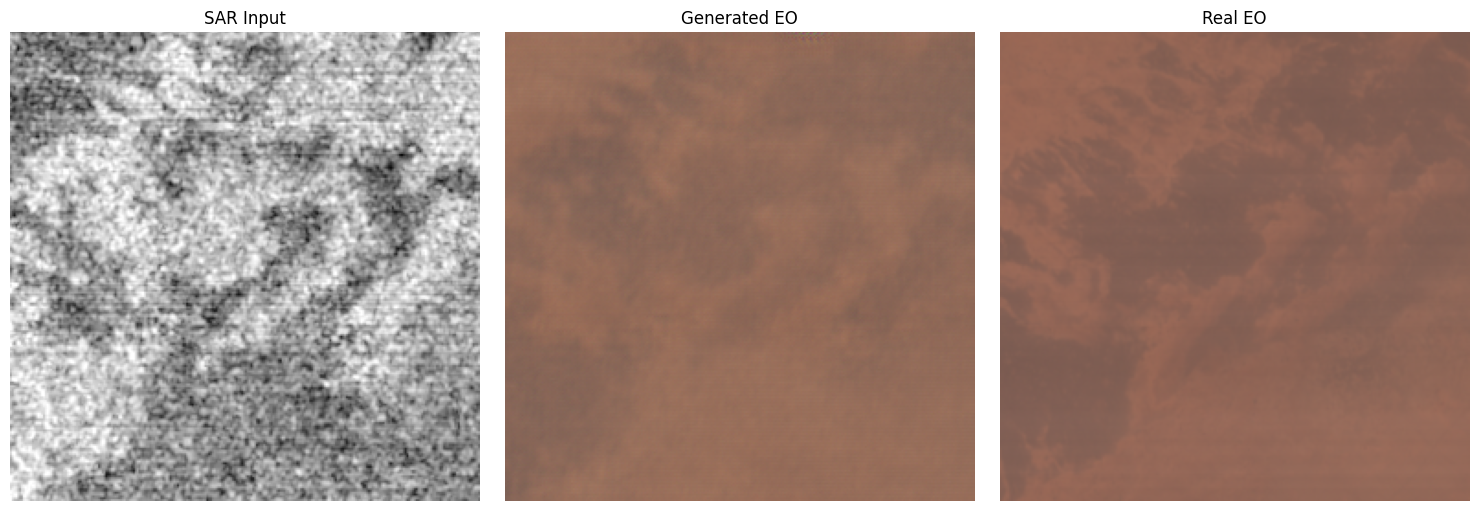

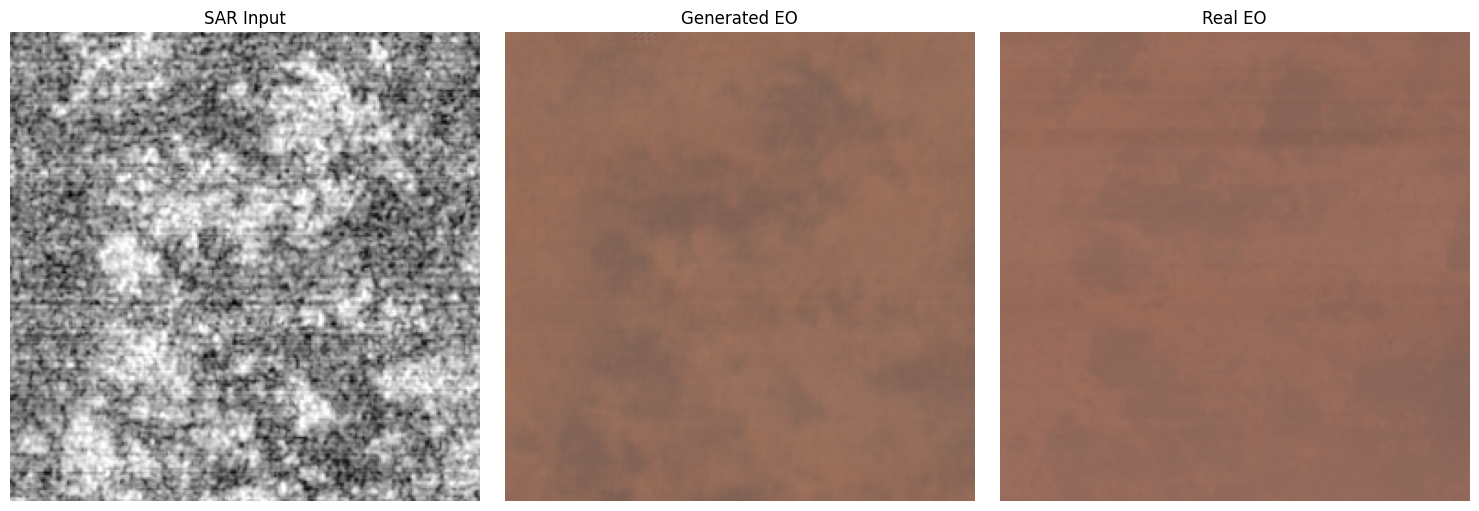

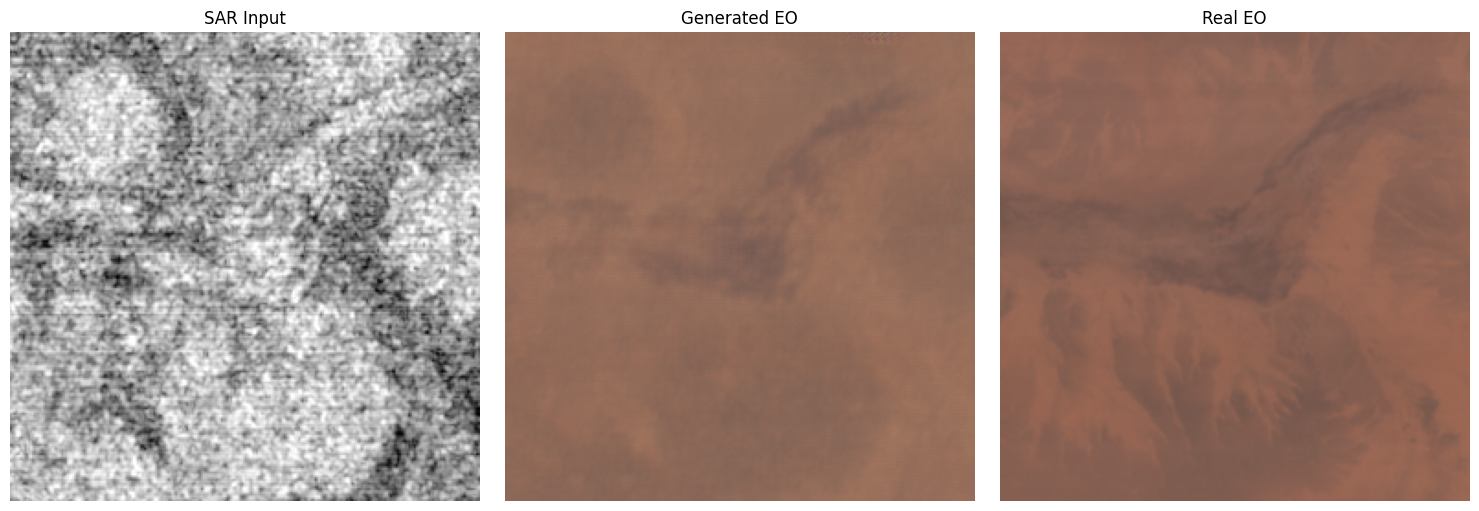

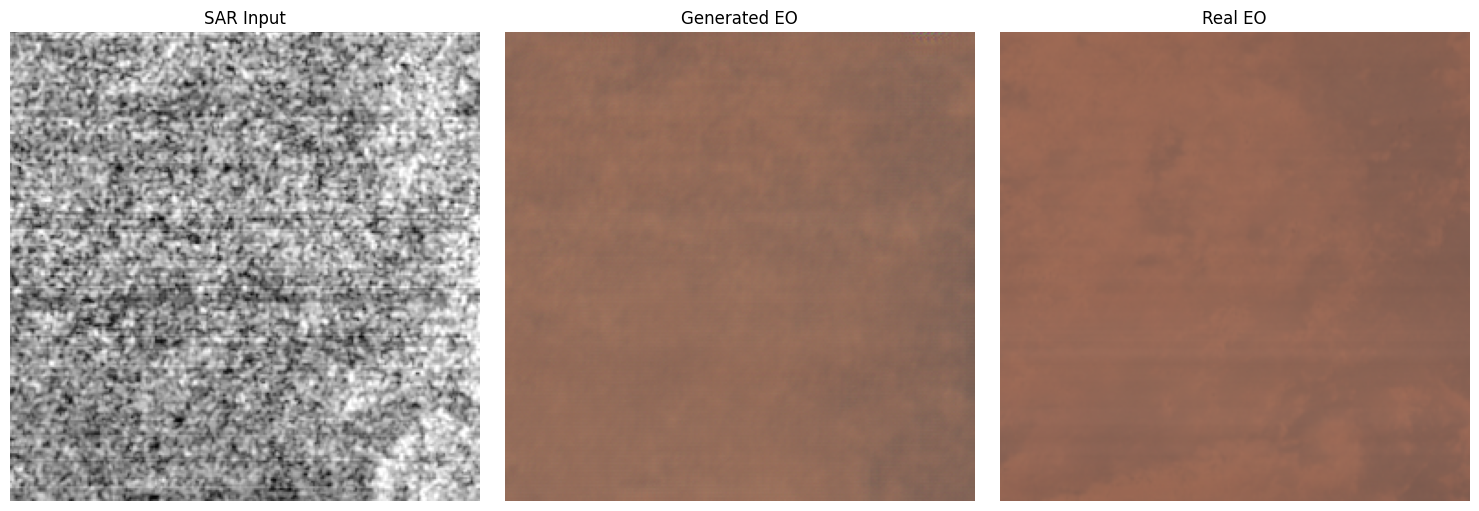

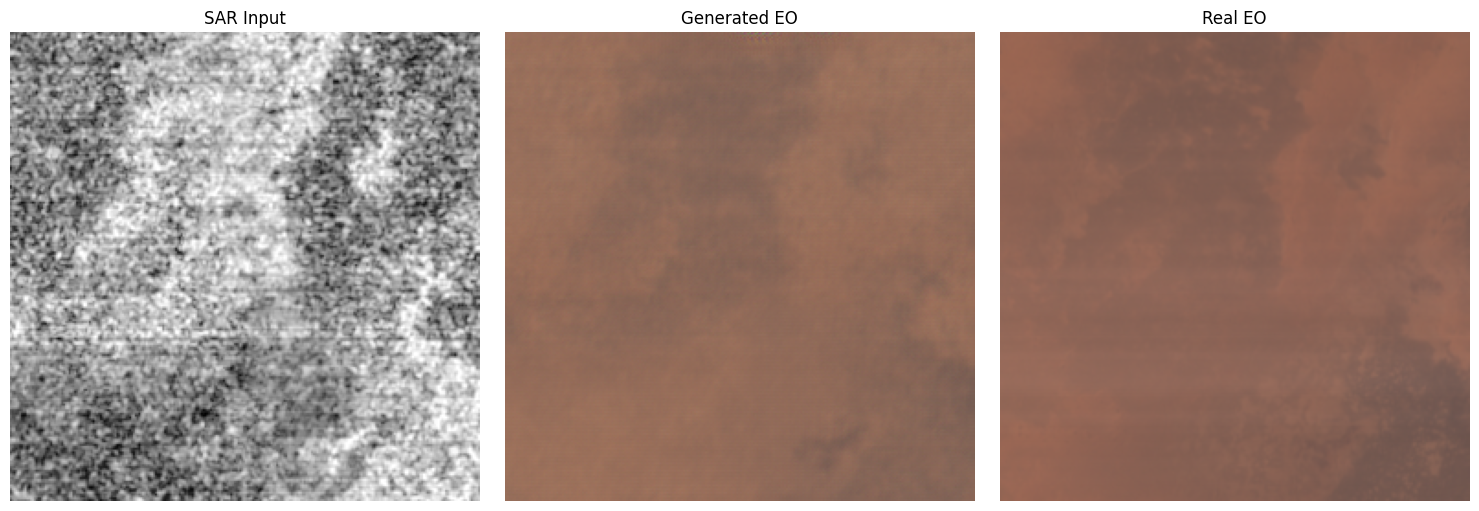

In [30]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def denormalize(img_tensor):
    # Assumes input is in [-1, 1], convert to [0, 1] for visualization
    return (img_tensor + 1) / 2

def plot_images(sar, fake_eo, real_eo, idx):
    sar_img = denormalize(sar.cpu()).numpy()
    fake_img = denormalize(fake_eo.cpu()).numpy()
    real_img = denormalize(real_eo.cpu()).numpy()

    # For EO (13-band), pick RGB bands (e.g., bands 4,3,2)
    sar_show = np.transpose(sar_img, (1, 2, 0))
    fake_show = np.transpose(fake_img[[3,2,1]], (1, 2, 0))  # fake EO RGB
    real_show = np.transpose(real_img[[3,2,1]], (1, 2, 0))  # real EO RGB

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(sar_show[..., 0], cmap='gray')  # show 1st SAR band
    axs[0].set_title("SAR Input")
    axs[1].imshow(np.clip(fake_show, 0, 1))
    axs[1].set_title("Generated EO")
    axs[2].imshow(np.clip(real_show, 0, 1))
    axs[2].set_title("Real EO")
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# === Inference and plot ===
G_AB.eval()
with torch.no_grad():
    for i, (sar, eo) in enumerate(test_loader):
        if i >= 5: break  # Visualize first 5 samples
        sar, eo = sar.to(DEVICE), eo.to(DEVICE)
        fake_eo = G_AB(sar)
        plot_images(sar[0], fake_eo[0], eo[0], i)
